# Price anomaly detection with an LSTM autoencoder
**Problem:** Flag unusual price behaviour automatically, without labelled anomalies.
**Approach:** Standardise closing prices, build 30-day windows, and train an LSTM encoder–decoder to reconstruct normal sequences. Test windows whose reconstruction error (MAE) goes above the 99th percentile of the training error are flagged as anomalies and plotted on the price chart.
**Data:** Public Yahoo Finance history for `SDGR`.
**Attribution:** follows the LSTM-autoencoder anomaly-detection walkthrough by Venelin Valkov (curiousily, *Deep Learning for Hackers*), applied to a different ticker.
**Notes:** the 5% test split must stay longer than the 30-step window. With SDGR's current history it's about 60 trading days.

In [1]:
import numpy as np
import tensorflow as tf
from tensorflow import keras
import pandas as pd
import seaborn as sns
from pylab import rcParams
import matplotlib.pyplot as plt
from matplotlib import rc
from pandas.plotting import register_matplotlib_converters

import yfinance as yf

%matplotlib inline
%config InlineBackend.figure_format='retina'

register_matplotlib_converters()
sns.set(style='whitegrid', palette='muted', font_scale=1.5)

rcParams['figure.figsize'] = 22, 10

RANDOM_SEED = 42

np.random.seed(RANDOM_SEED)
tf.random.set_seed(RANDOM_SEED)

In [2]:
ticker = "SDGR"

In [3]:
stock = yf.Ticker(ticker)
df = stock.history(period="max")

In [4]:
df.describe()

,Open,High,Low,Close,Volume,Dividends,Stock Splits
count,1670.000000,1670.000000,1670.000000,1670.000000,1.670000e+03,1670.0,1670.0
mean,35.445163,36.487514,34.385283,35.416862,9.750383e+05,0.0,0.0
std,21.296956,21.901057,20.605392,21.238650,7.949318e+05,0.0,0.0
min,11.150000,11.400000,10.945000,11.070000,1.569000e+05,0.0,0.0
25%,20.585000,21.110000,20.049999,20.580000,5.717750e+05,0.0,0.0
50%,26.700001,27.389999,25.884999,26.639999,7.872000e+05,0.0,0.0
75%,47.057500,49.067500,45.042500,47.117499,1.121275e+06,0.0,0.0
max,112.790001,117.000000,109.330002,113.089996,1.327110e+07,0.0,0.0


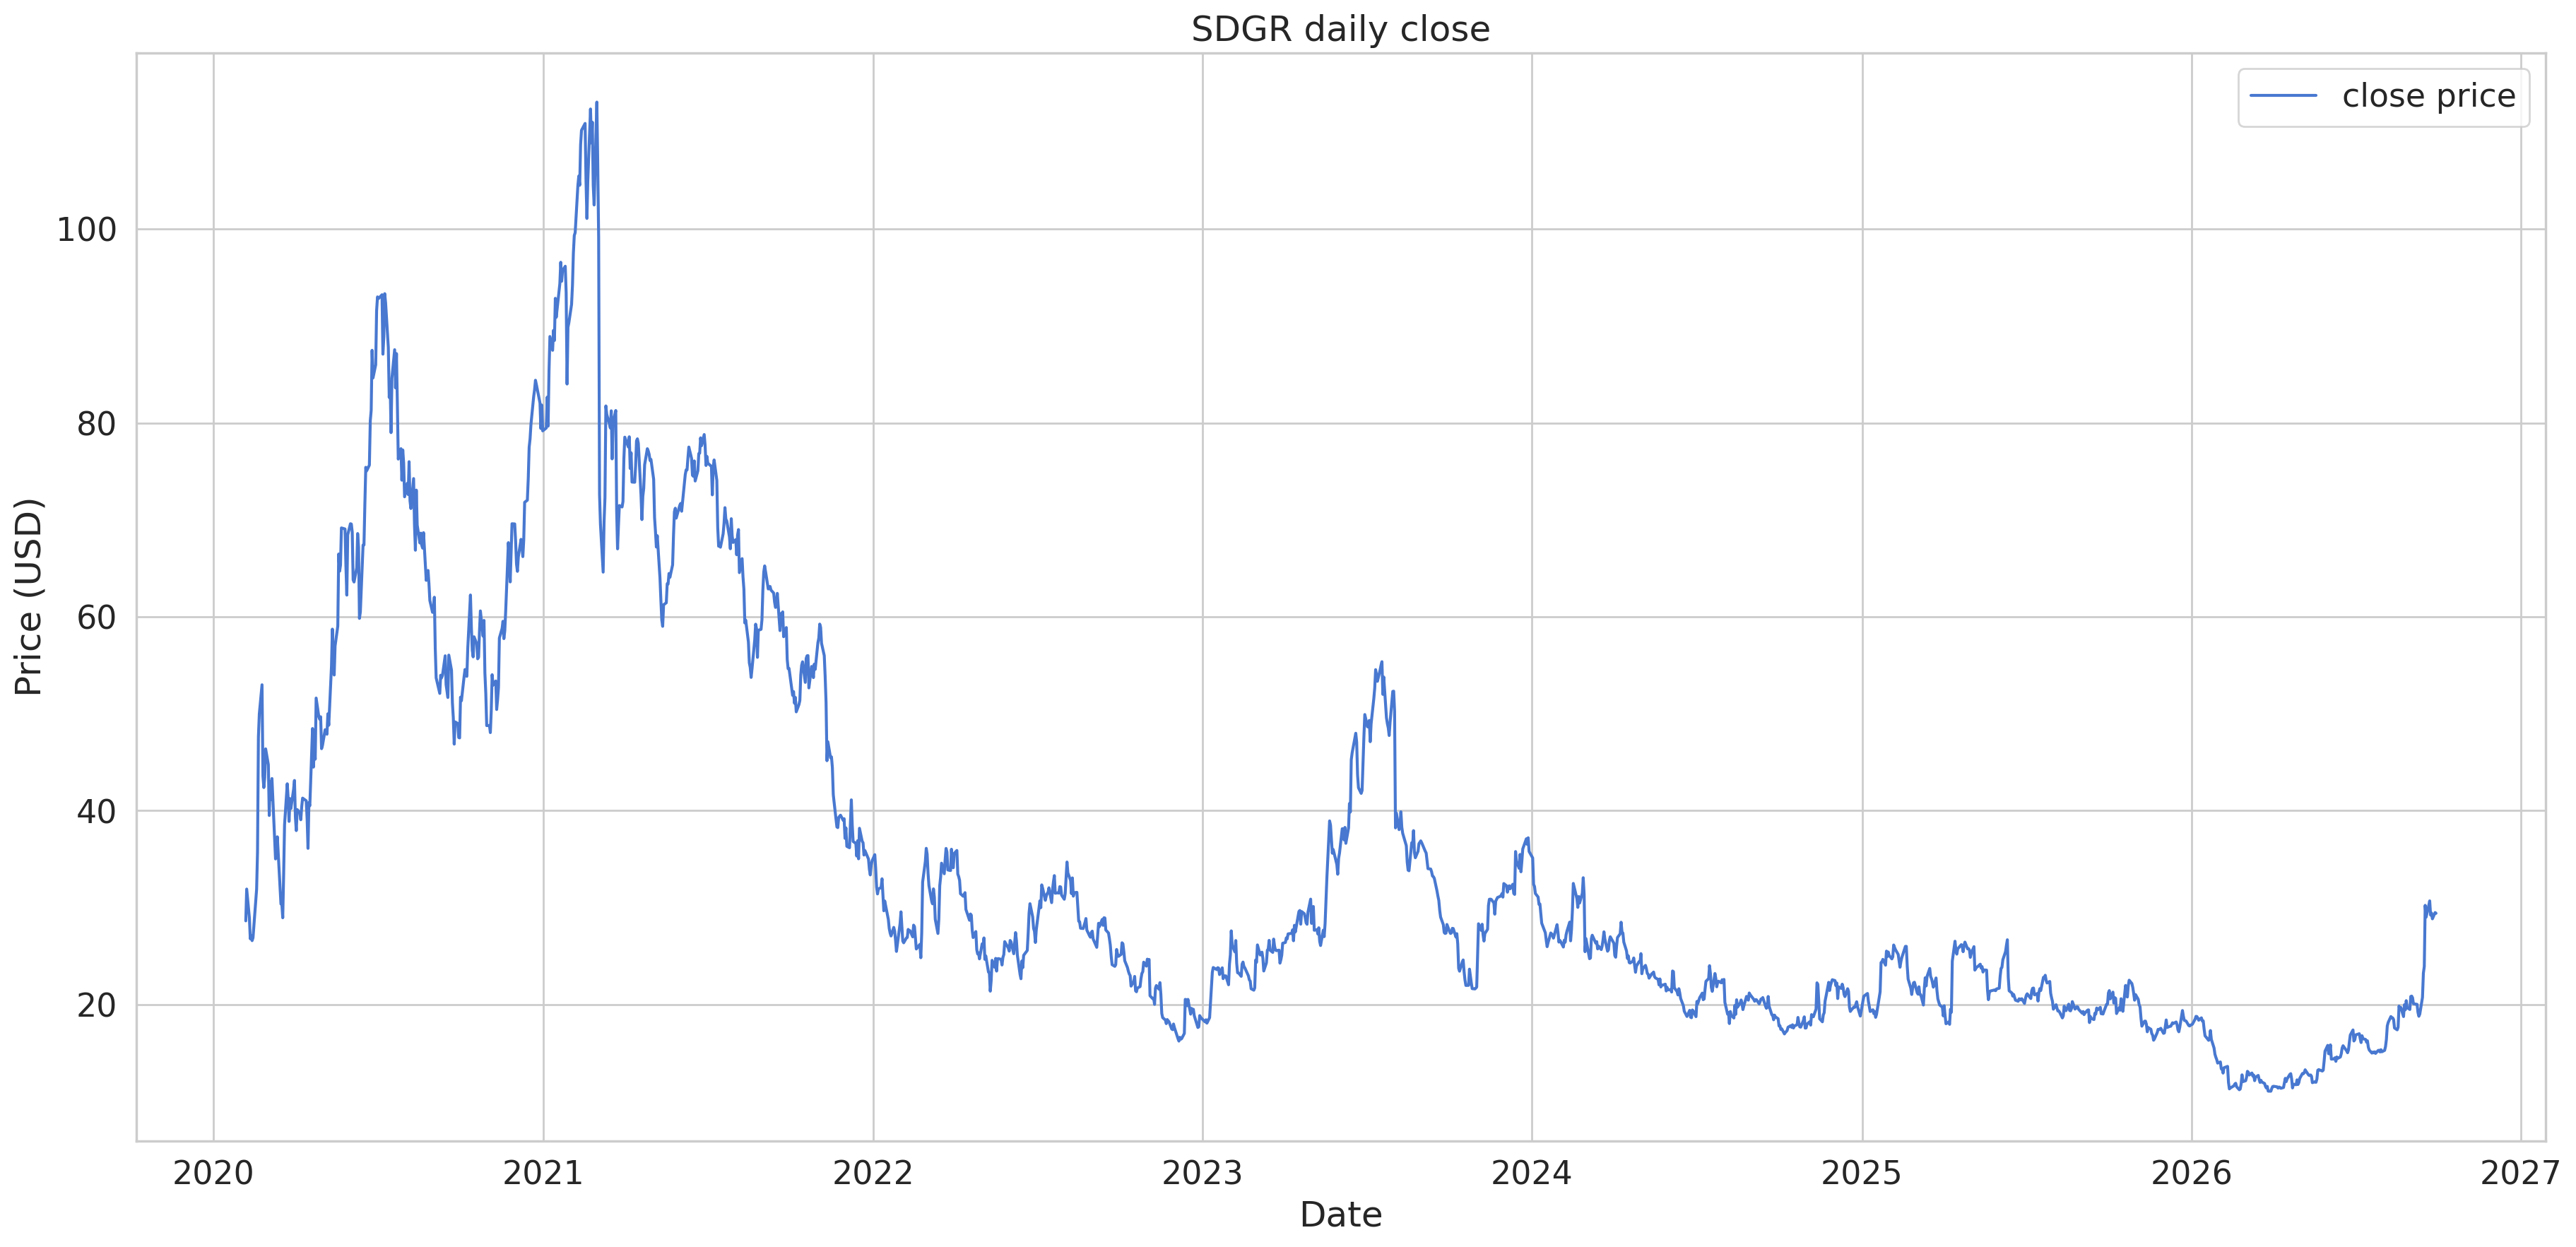

In [5]:
plt.plot(df['Close'], label='close price')
plt.title(f'{ticker} daily close')
plt.xlabel('Date')
plt.ylabel('Price (USD)')
plt.legend();

## Train/test split and scaling

In [6]:
train_size = int(len(df) * 0.95)
test_size = len(df) - train_size
train, test = df.iloc[0:train_size].copy(), df.iloc[train_size:len(df)].copy()
print(train.shape, test.shape)

(1586, 7) (84, 7)


In [7]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
scaler = scaler.fit(train[['Close']])

train['Close'] = scaler.transform(train[['Close']])
test['Close'] = scaler.transform(test[['Close']])

## Build sliding windows

In [8]:
def create_dataset(X, y, time_steps=1):
    Xs, ys = [], []
    for i in range(len(X) - time_steps):
        v = X.iloc[i:(i + time_steps)].values
        Xs.append(v)        
        ys.append(y.iloc[i + time_steps])
    return np.array(Xs), np.array(ys)

In [9]:
TIME_STEPS = 30

# reshape to [samples, time_steps, n_features]

X_train, y_train = create_dataset(train[['Close']], train.Close, TIME_STEPS)
X_test, y_test = create_dataset(test[['Close']], test.Close, TIME_STEPS)

print(X_train.shape)

(1556, 30, 1)


## LSTM autoencoder model

In [10]:
model = keras.Sequential()
model.add(keras.layers.LSTM(
    units=64, 
    input_shape=(X_train.shape[1], X_train.shape[2])
))
model.add(keras.layers.Dropout(rate=0.2))
model.add(keras.layers.RepeatVector(n=X_train.shape[1]))
model.add(keras.layers.LSTM(units=64, return_sequences=True))
model.add(keras.layers.Dropout(rate=0.2))
model.add(keras.layers.TimeDistributed(keras.layers.Dense(units=X_train.shape[2])))
model.compile(loss='mae', optimizer='adam')

In [11]:
# An autoencoder learns to reproduce its input window, so the target is X_train itself.
# (The source tutorial trained on y_train, the next value, and then scored reconstruction
# error against the input window, which is inconsistent.)
history = model.fit(
    X_train, X_train,
    epochs=10,
    batch_size=32,
    validation_split=0.1,
    shuffle=False
)

Epoch 1/10


 1/44 [..............................] - ETA: 3:18 - loss: 0.2336

 4/44 [=>............................] - ETA: 0s - loss: 0.8798  

 7/44 [===>..........................] - ETA: 0s - loss: 0.6859

10/44 [=====>........................] - ETA: 0s - loss: 0.7148

...

35/44 [======================>.......] - ETA: 0s - loss: 0.2472

38/44 [========================>.....] - ETA: 0s - loss: 0.2392

41/44 [==========================>...] - ETA: 0s - loss: 0.2309

44/44 [==============================] - ETA: 0s - loss: 0.2227

44/44 [==============================] - 1s 24ms/step - loss: 0.2227 - val_loss: 0.0840


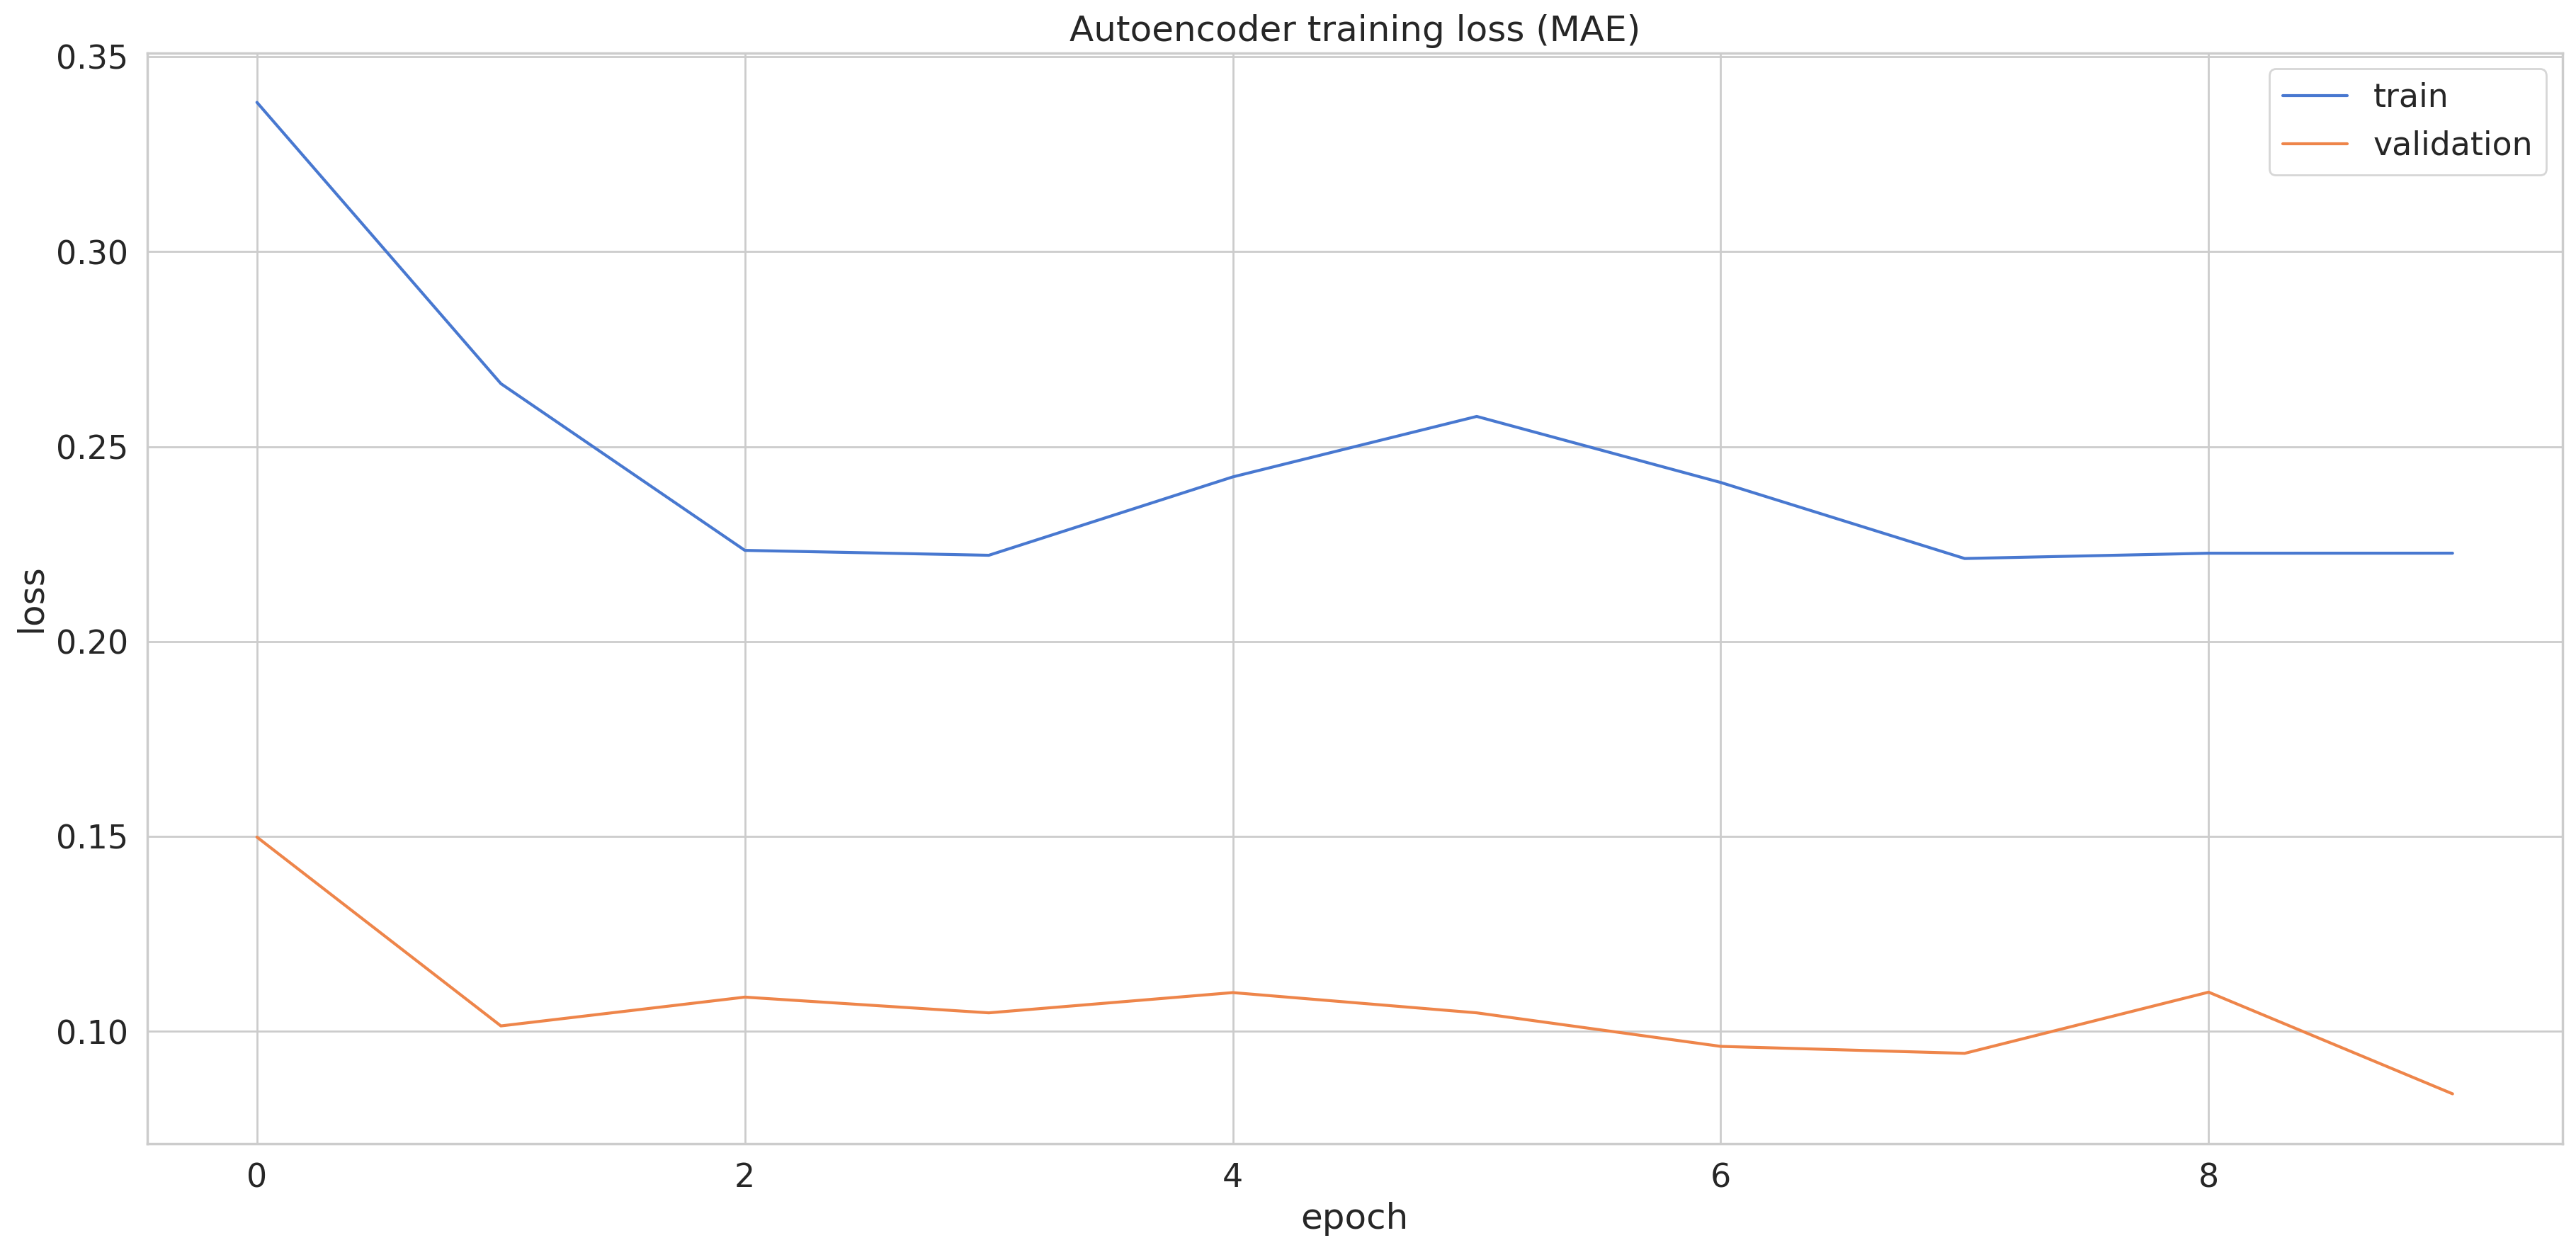

In [12]:
plt.plot(history.history['loss'], label='train')
plt.plot(history.history['val_loss'], label='validation')
plt.title('Autoencoder training loss (MAE)')
plt.xlabel('epoch')
plt.ylabel('loss')
plt.legend();

## Reconstruction error → anomaly threshold

In [13]:
X_train_pred = model.predict(X_train)

train_mae_loss = np.mean(np.abs(X_train_pred - X_train), axis=1)

 1/49 [..............................] - ETA: 47s

 7/49 [===>..........................] - ETA: 0s 

14/49 [=======>......................] - ETA: 0s

22/49 [============>.................] - ETA: 0s

30/49 [=================>............] - ETA: 0s

38/49 [======================>.......] - ETA: 0s

46/49 [===========================>..] - ETA: 0s

49/49 [==============================] - 1s 7ms/step


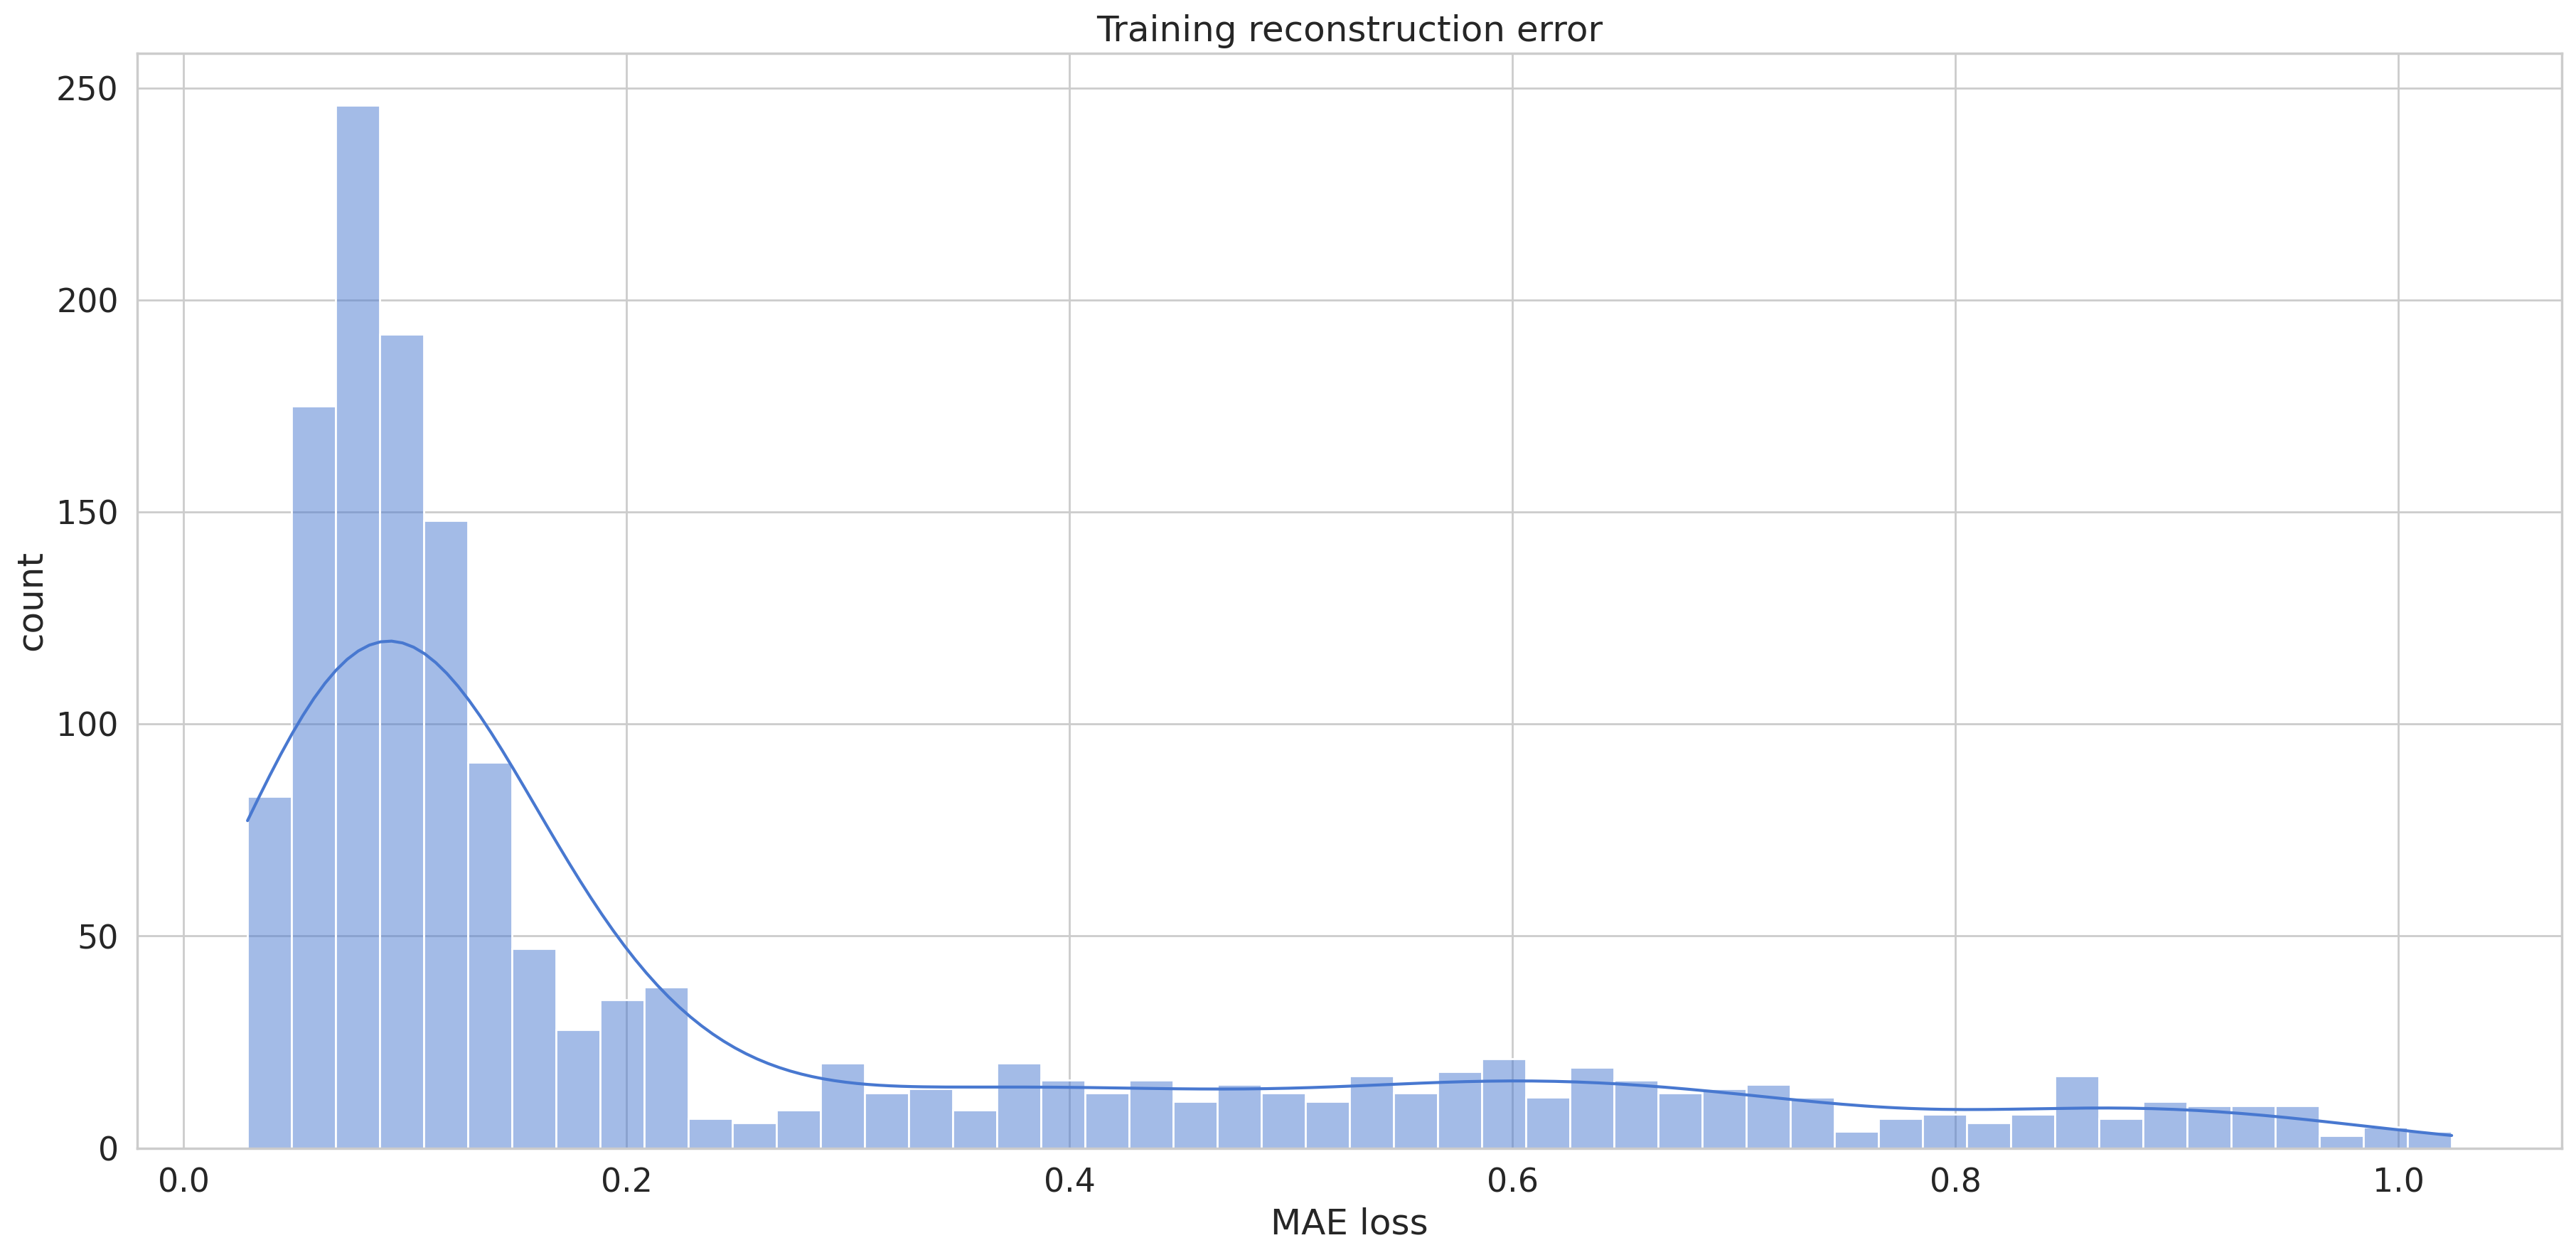

In [14]:
sns.histplot(train_mae_loss.ravel(), bins=50, kde=True)
plt.title('Training reconstruction error')
plt.xlabel('MAE loss')
plt.ylabel('count');

In [15]:
X_test_pred = model.predict(X_test)

test_mae_loss = np.mean(np.abs(X_test_pred - X_test), axis=1)

1/2 [==============>...............] - ETA: 0s

2/2 [==============================] - 0s 7ms/step


## Flag and plot anomalies

In [16]:
# Data-driven threshold: flag test windows whose reconstruction error exceeds the 99th
# percentile of the training error. The original fixed 0.65 was tuned to 2021 data and
# flags nothing on today's history.
THRESHOLD = float(np.percentile(train_mae_loss, 99))
print(f'threshold (99th pct of training MAE): {THRESHOLD:.3f}')

test_score_df = pd.DataFrame(index=test[TIME_STEPS:].index)
test_score_df['loss'] = test_mae_loss.ravel()
test_score_df['threshold'] = THRESHOLD
test_score_df['anomaly'] = test_score_df.loss > test_score_df.threshold
test_score_df['Close'] = test[TIME_STEPS:].Close

threshold (99th pct of training MAE): 0.960


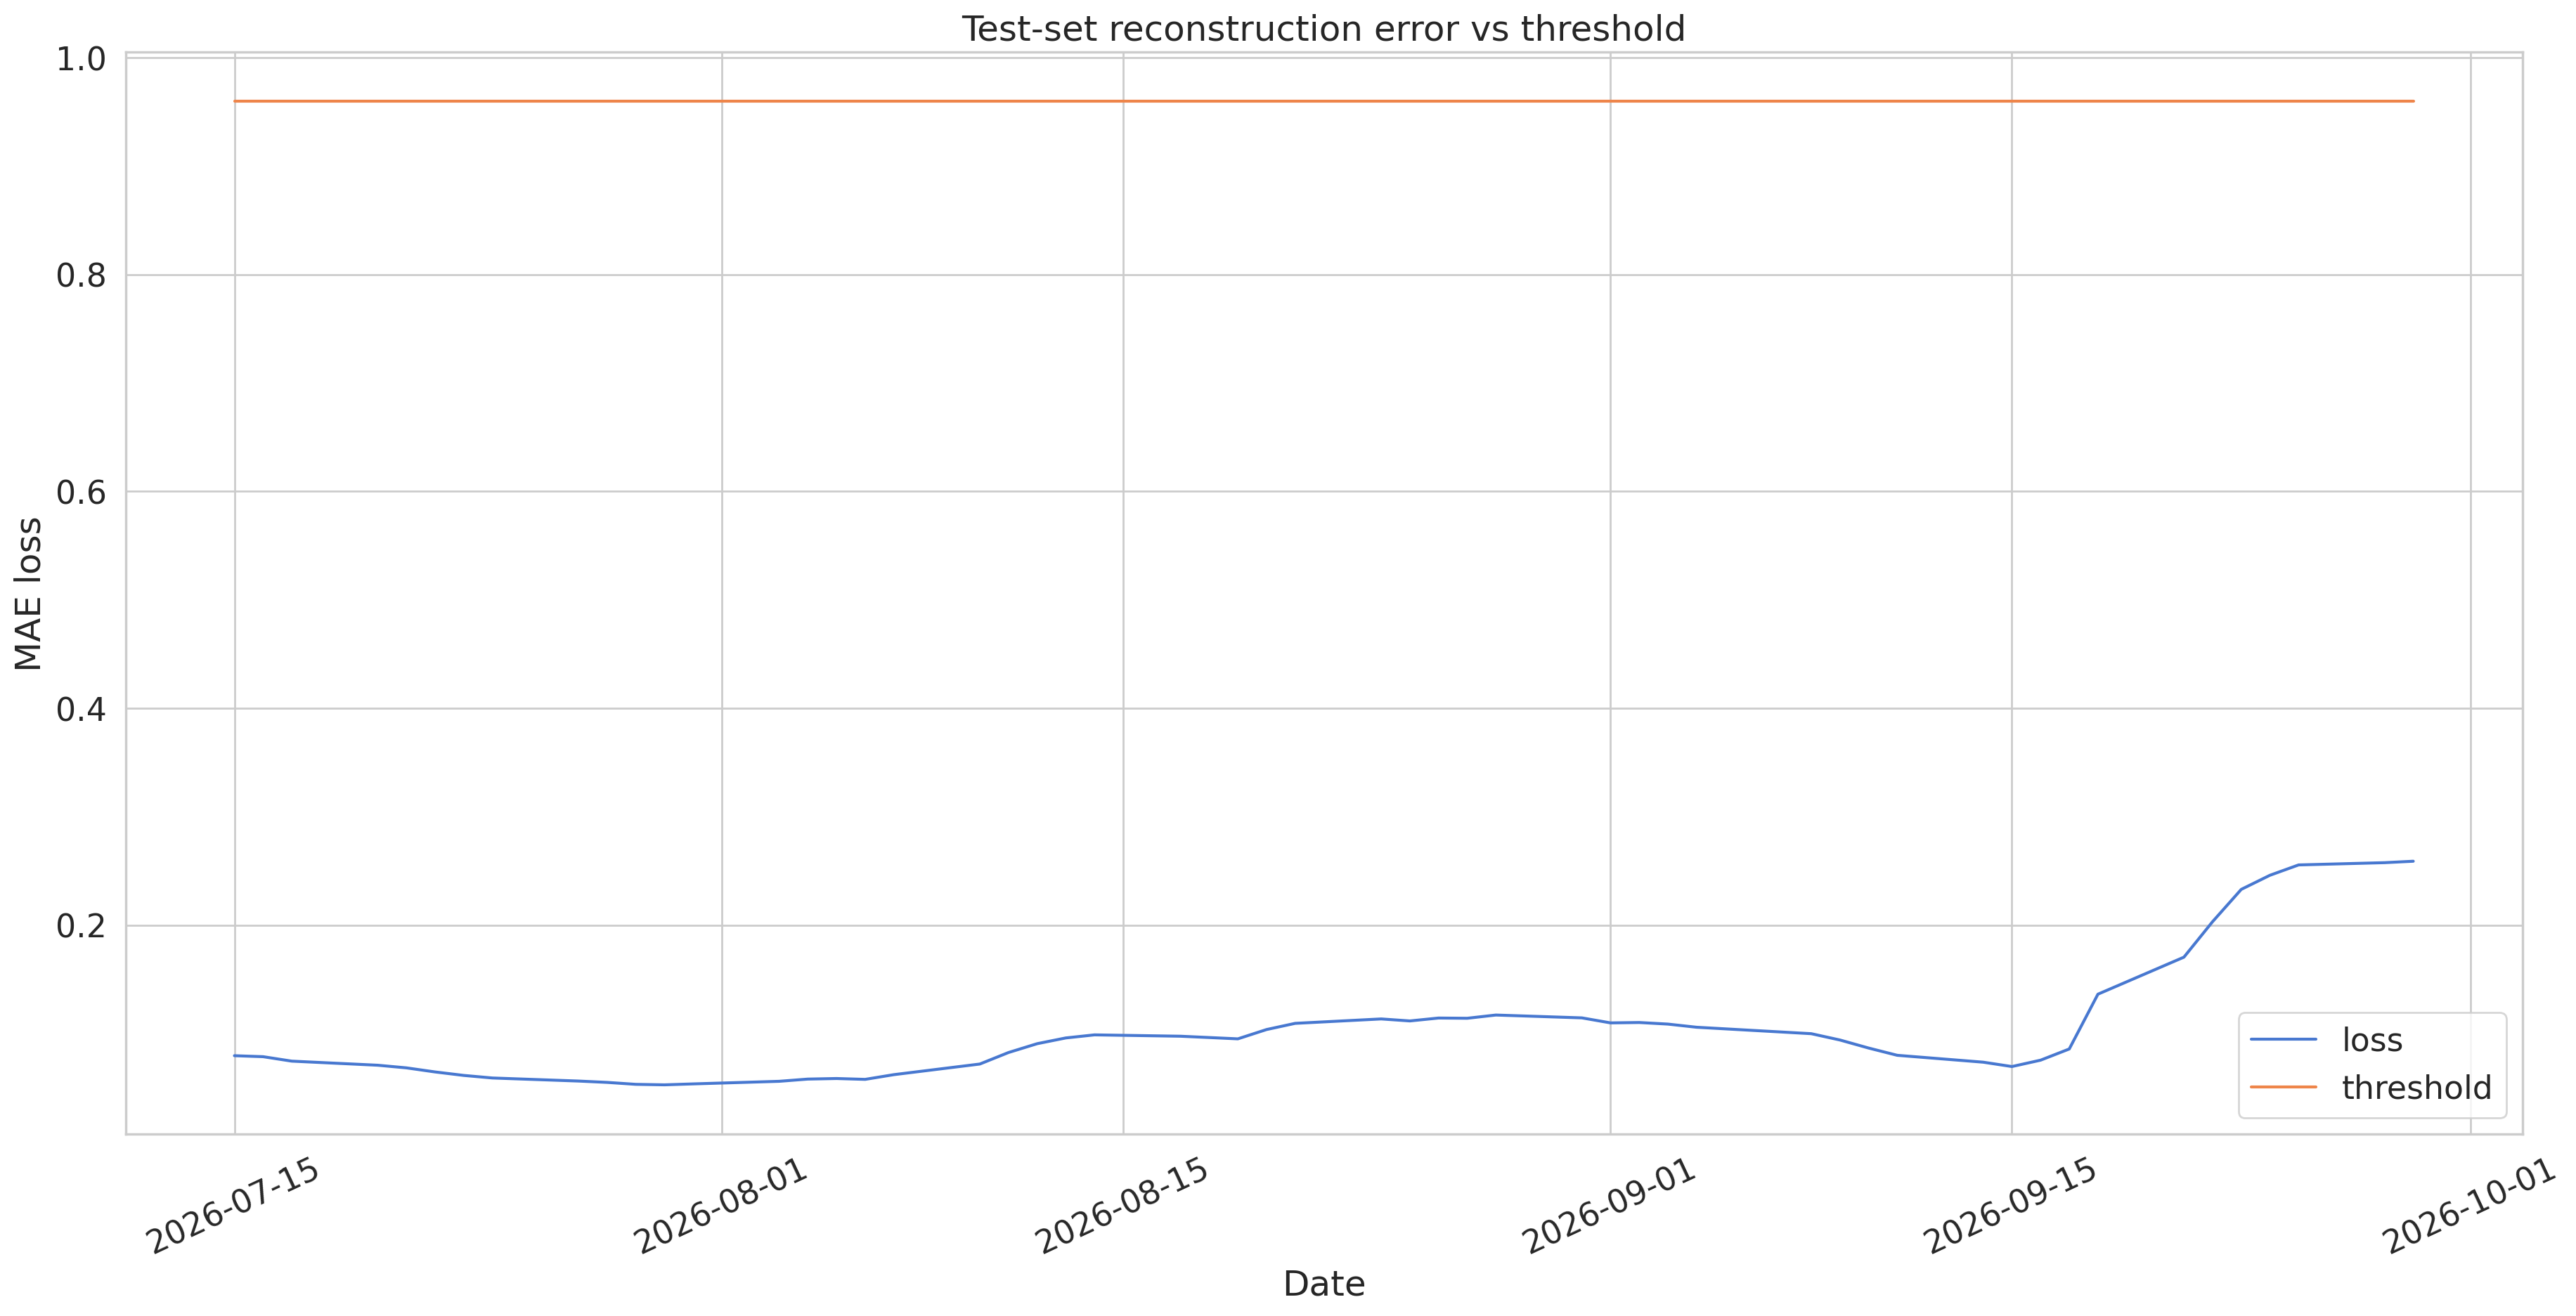

In [17]:
plt.plot(test_score_df.index, test_score_df.loss, label='loss')
plt.plot(test_score_df.index, test_score_df.threshold, label='threshold')
plt.title('Test-set reconstruction error vs threshold')
plt.xlabel('Date')
plt.ylabel('MAE loss')
plt.xticks(rotation=25)
plt.legend();

In [18]:
anomalies = test_score_df[test_score_df.anomaly == True]
anomalies.head()

,loss,threshold,anomaly,Close
Date,,,,


No anomalies above the threshold in the test period.


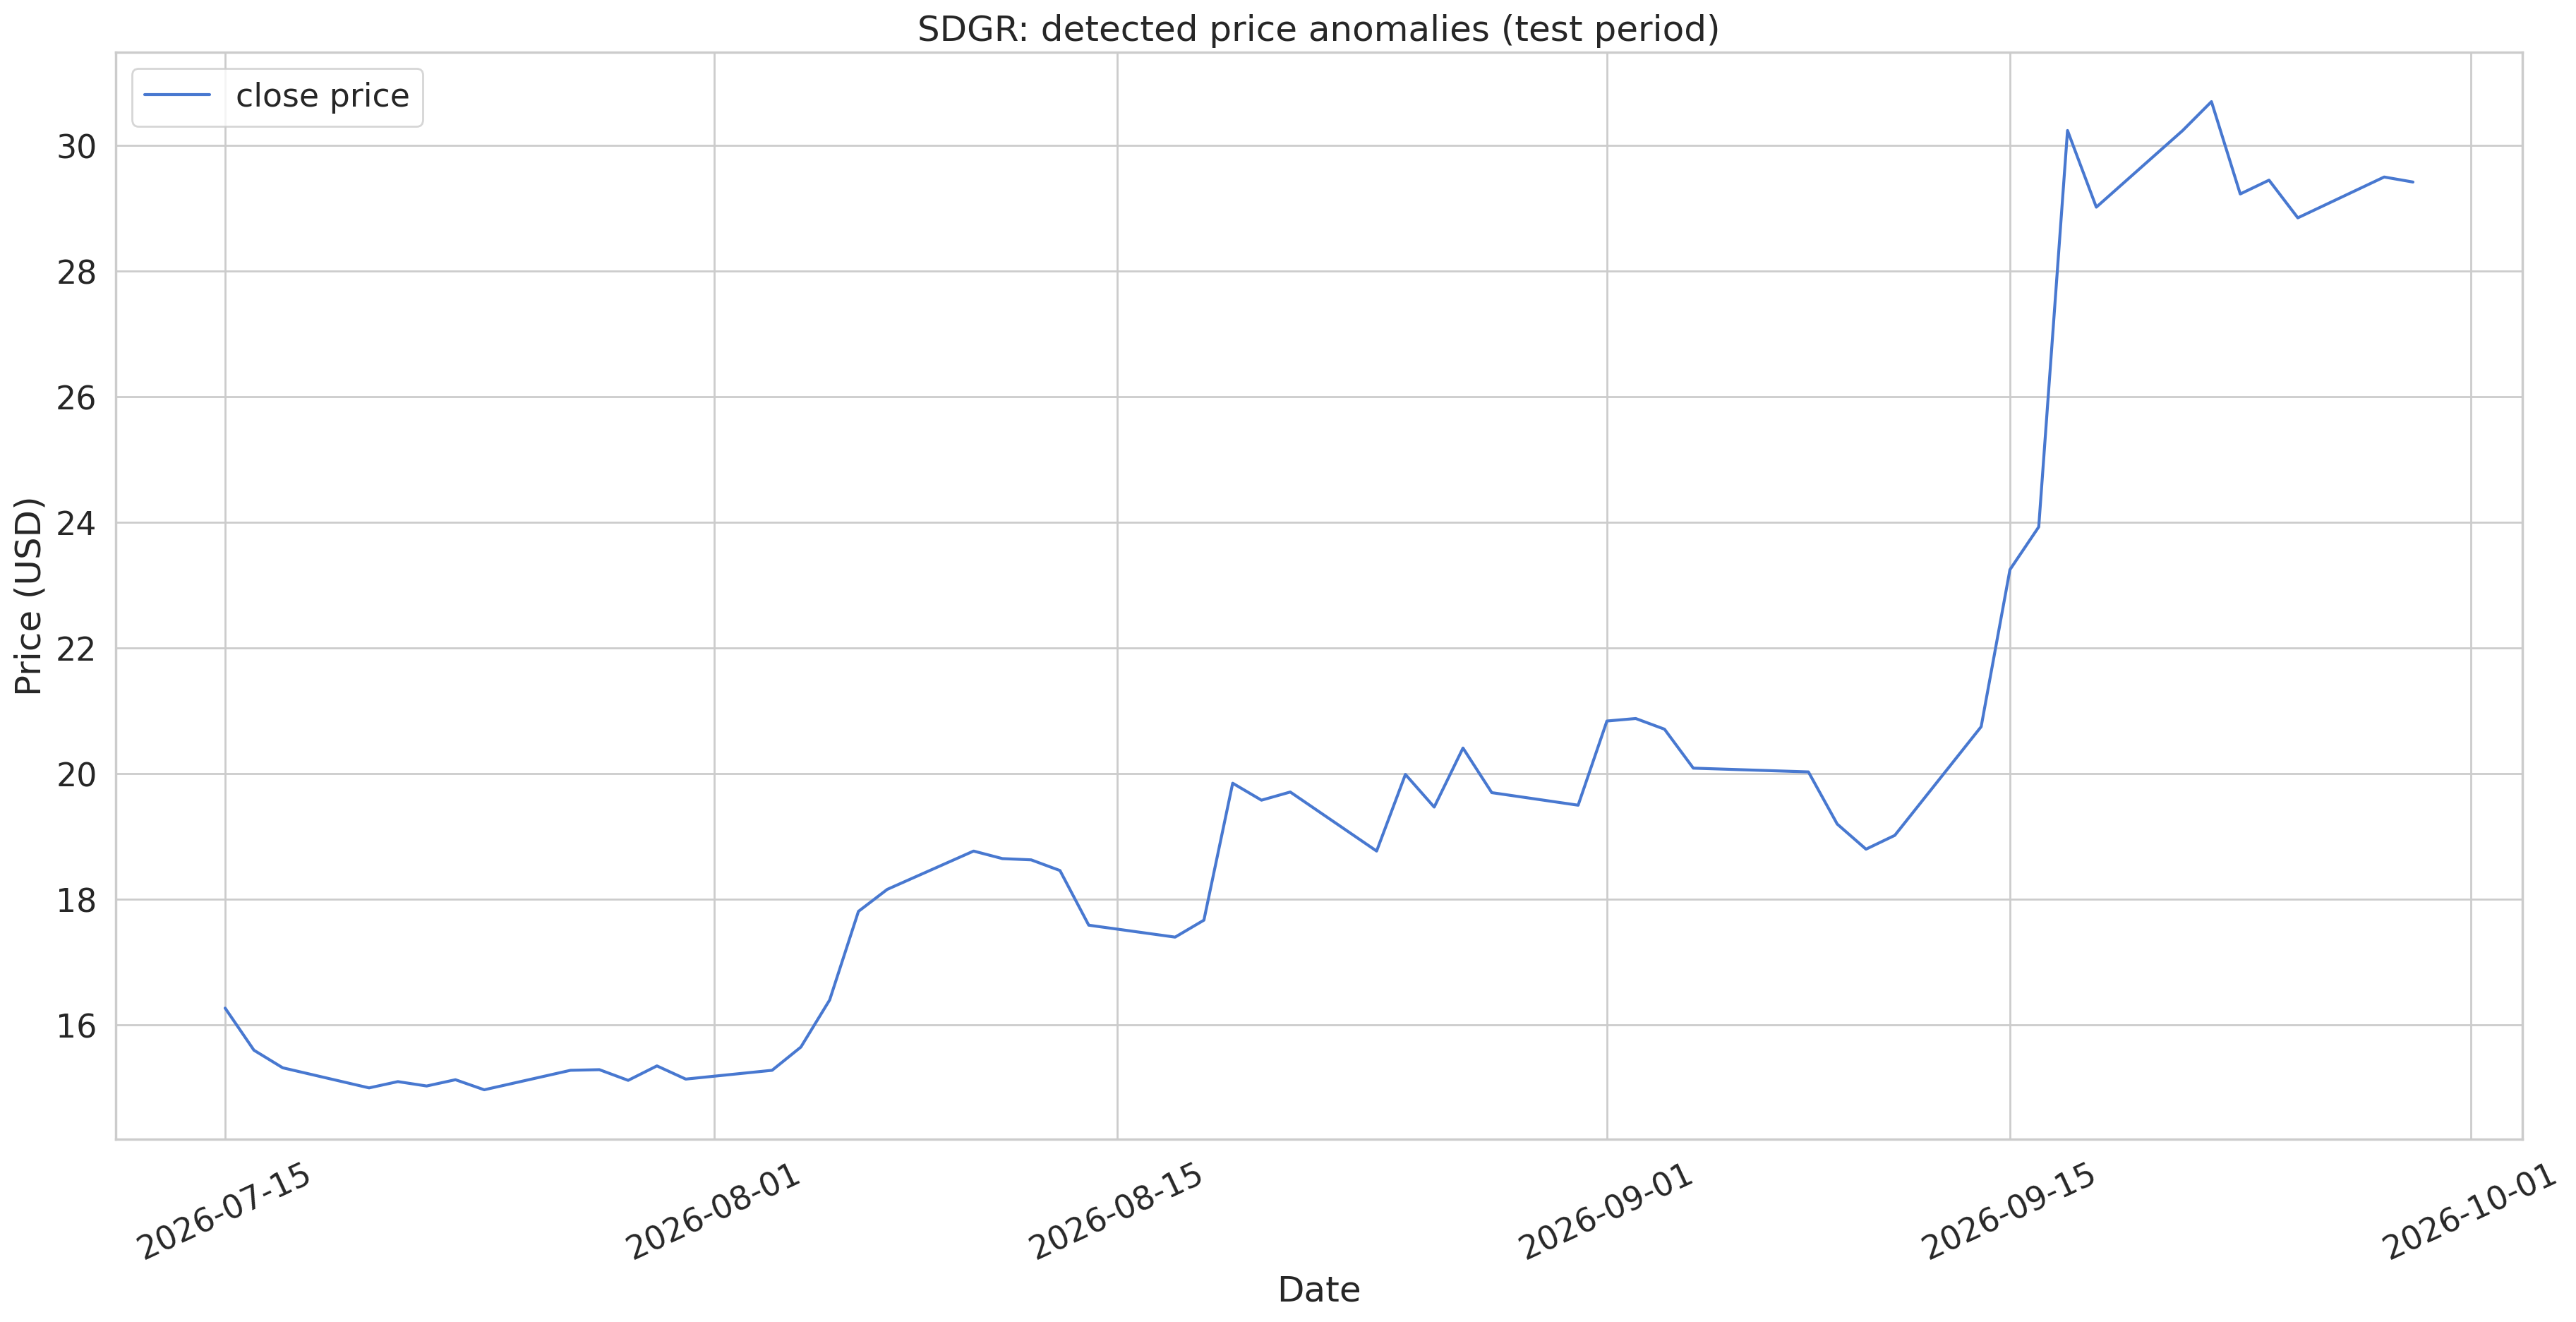

In [19]:
plt.plot(
  test[TIME_STEPS:].index,
  scaler.inverse_transform(test[TIME_STEPS:][['Close']]).ravel(),
  label='close price'
);

if anomalies.empty:
    print('No anomalies above the threshold in the test period.')
else:
    sns.scatterplot(
        x=anomalies.index,
        y=scaler.inverse_transform(anomalies[['Close']]).ravel(),
        color=sns.color_palette()[3],
        s=52,
        label='anomaly'
    )
plt.title(f'{ticker}: detected price anomalies (test period)')
plt.xlabel('Date')
plt.ylabel('Price (USD)')
plt.xticks(rotation=25)
plt.legend();